# Atmospheric neutrinos from a *reanalysed* atmosphere

### ERA5 weather data → MCEq → the neutrino rate at IceCube

A pion (or kaon) born in a cosmic-ray shower has two futures: **decay** into a
neutrino, or **hit an air nucleus** first and make no neutrino at all. Which one wins
is decided by the density of the air around it — **warm air is thin, so more pions
decay and more neutrinos arrive; cold dense air means fewer.** A neutrino telescope
therefore cares what the weather is doing, and this notebook calculates it with real
weather data.

Same patch of Earth and same week as the AIRS notebook, so the two can be read
against each other.

## What you need to install

```bash
pip install MCEq cdsapi xarray netcdf4 matplotlib cartopy
pip install 'git+https://github.com/afedynitch/nrlmsis2.1'
```

You also need a free account at the [Copernicus Climate Data
Store](https://cds.climate.copernicus.eu), with the ERA5 licence accepted once and an
API key in `~/.cdsapirc`.

In [1]:
import gzip
import os

import cdsapi
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

G0 = 9.80665  # standard gravity, m/s^2

### Settings — everything you might want to change lives here

In [2]:
# One week of austral winter. Select to your liking.
# Change MONTH with them: it is the month the week falls in, and the climatology we
# compare against is picked by it.
START_DATE, END_DATE = "2013-08-05", "2013-08-11"
MONTH = "August"

# This is the "Earth patch" we want to download data for.
# We take 360deg in longitude and cut in latitude.
LAT_RANGE = (-90.0, -35.0)

# Storage
OUTPUT_DIR = "era5_tables"       # store output tables for MCEq here
NC_FILE = "era5_pressure_levels.nc"   # the weather download
ORO_FILE = "era5_orography.nc"        # the ground

# IceCube
SITE_LON, SITE_LAT = 0.0, -90.0   # Location
SITE_ELEVATION_M = 2835.0         # Surface elevation
SITE_DEPTH_M = 1948.0             # Depth of detector
E_THRESHOLD = 100.0  # energy threshold approx for neutrinos, we do not have effective area here, so we integrate counts above this value
ZENITH_BAND = np.linspace(90.0, 115.0, 11)  # the up-going band, same band as https://arxiv.org/pdf/2303.04682

# An up-going direction has a whole ring of azimuths around it; this many are
# averaged over. More is smoother and slower.
N_AZIMUTH = 12

# Make this notebook FAST
# For the map in Part 8, use only every 6th latitude and every 30th longitude.
LAT_STRIDE, LON_STRIDE = 6, 30

## 1. The whole MCEq recipe, in 8 lines

MCEq solves the **coupled cascade equations**: it predicts the statistical average
flux of cosmic-ray air showers and tracks how many particles of each species and
energy are produced.

To run **these 8 lines** we need to **convert the ERA5 data to .csv format**:

```python
import crflux.models as pm
import MCEq.geometry.density_profiles as dp
from MCEq.core import MCEqRun

# Load an ERA5 (or other weather) table
table = dp.AtmosphereTable.load_from_csv("my_atmosphere.csv.gz")

# Construct the Atmosphere with it
atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),   # lon, lat
                             surface_elevation_m=SITE_ELEVATION_M)     # where the ground is

# Build an MCEq instance
mceq = MCEqRun(interaction_model="SIBYLL2.3E",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=atm)

# Solve the Cascade Equations
mceq.solve()
flux = mceq.get_solution("total_numu")   # Flux, per cm^2 s sr GeV
```

The CSV is a plain text table of height, temperature and pressure — it can come from
**any** source. Here it comes from a weather archive.

### The route from ERA5 data to a neutrino flux

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


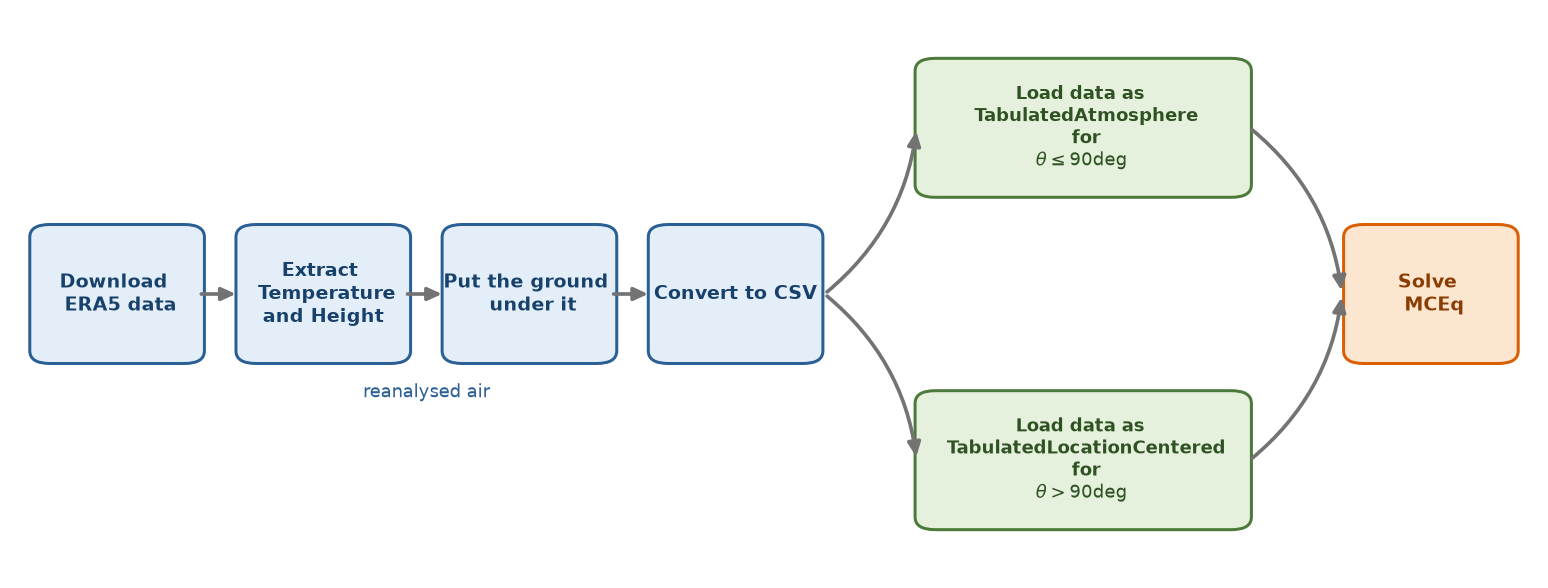

In [3]:
from matplotlib.patches import FancyBboxPatch

# Four steps to the table, then a fork: the direction you look decides which
# class reads it.  Every label is in words the reader already has.
chain = ["Download \n ERA5 data", "Extract \n Temperature\nand Height",
         "Put the ground \n under it", "Convert to CSV"]
fork = [("Load data as \n TabulatedAtmosphere\n for\n" + r"$\theta \leq 90\deg$"),
        ("Load data as \n TabulatedLocationCentered\n for\n" + r"$\theta > 90\deg$")]

BW, GAP, BH = 0.20, 0.055, 0.26
fig, ax = plt.subplots(figsize=(13, 5.0), dpi=120)


def box(x, y, w, h, title, fc, ec, tc, ts=11.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.008,rounding_size=0.025",
                                fc=fc, ec=ec, lw=1.8))
    ax.text(x + w / 2, y + h * 0.50, title, ha="center", va="center",
            fontsize=ts, color=tc, weight="semibold")


def arrow(x0, y0, x1, y1, rad=0.0):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>,head_width=0.32,head_length=0.7",
                                color="0.45", lw=2.2,
                                connectionstyle=f"arc3,rad={rad}"))


MID = 0.50
for k, title in enumerate(chain):
    x = k * (BW + GAP)
    box(x, MID - BH / 2, BW, BH, title, "#e3eef8", "#2a5f95", "#17416b")
    if k:
        arrow(x - GAP, MID, x - 0.004, MID)
CHAIN_END = 3 * (BW + GAP) + BW

FX, FW = CHAIN_END + 0.13, 0.40
for k, title in enumerate(fork):
    y = MID + 0.20 if k == 0 else MID - 0.20 - BH
    box(FX, y, FW, BH, title, "#e6f1dd", "#4b7a3a", "#2f5223", ts=11)
    arrow(CHAIN_END + 0.01, MID, FX - 0.006, y + BH / 2, rad=0.20 if k == 0 else -0.20)
    arrow(FX + FW + 0.006, y + BH / 2, FX + FW + 0.12, MID, rad=0.20 if k == 1 else -0.20)

MX = FX + FW + 0.13
box(MX, MID - BH / 2, BW, BH, "Solve \n MCEq", "#fce6d0", "#d95f02", "#8a3d02")

ax.text(CHAIN_END / 2, MID - BH / 2 - 0.075, "reanalysed air", fontsize=10.5,
        color="#2a5f95", ha="center")
ax.set_xlim(-0.03, MX + BW + 0.03)
ax.set_ylim(MID - 0.20 - BH - 0.10, MID + 0.20 + BH + 0.10)
ax.axis("off")
fig.tight_layout()

## 2. What ERA5 is

* **ERA5** is the ECMWF **reanalysis**: a weather model re-run over the past, steered
  at every step by the observations actually taken — radiosondes, aircraft,
  satellites. It is not a measurement, and it is not a forecast; it is the best
  estimate of what the atmosphere was doing.
* We use the pressure-level product: temperature and geopotential on **37 pressure
  levels** (1000 → 1 hPa), everywhere, every day.
* $T$ and $p$ give density through the ideal gas law; geopotential says at what
  **altitude** to put it. That is everything MCEq needs.

### The catch

Its pressure levels do not stop at the ground. Below the terrain they are
**extrapolated** and fictitious, and nothing in the file marks where the real surface
is — so the ground has to be fetched separately, as its own field.

## 3. Getting the data

You **need a free [CDS account](https://cds.climate.copernicus.eu)**, the **ERA5
licence accepted once** on the dataset's own download page, and an **API key in
`~/.cdsapirc`** (see <https://cds.climate.copernicus.eu/how-to-api>).

Two downloads: the weather for the week, and the ground under it. The server does the
cutting — we name the patch and the grid, and it sends back only that.

In [4]:
DAYS = [f"{d:02d}" for d in range(int(START_DATE[8:10]), int(END_DATE[8:10]) + 1)]
AREA = [LAT_RANGE[1], -180, LAT_RANGE[0], 180]   # north, west, south, east

if not os.path.exists(NC_FILE):
    cdsapi.Client().retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": ["reanalysis"],
            "variable": ["temperature", "geopotential"],
            "pressure_level": ["1", "2", "3", "5", "7", "10", "20", "30", "50", "70",
                               "100", "125", "150", "175", "200", "225", "250", "300",
                               "350", "400", "450", "500", "550", "600", "650", "700",
                               "750", "775", "800", "825", "850", "875", "900", "925",
                               "950", "975", "1000"],
            "year": [START_DATE[:4]], "month": [START_DATE[5:7]], "day": DAYS,
            "time": ["12:00"],
            "grid": [1.0, 1.0], "area": AREA,
            "data_format": "netcdf", "download_format": "unarchived",
        },
        NC_FILE,
    )

if not os.path.exists(ORO_FILE):
    cdsapi.Client().retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": ["reanalysis"], "variable": ["geopotential"],
            # Any date at all: the terrain is a fixed field, so this one is not
            # START_DATE and you never need to change it.
            "year": ["2013"], "month": ["08"], "day": ["01"], "time": ["12:00"],
            "area": AREA,
            "data_format": "netcdf", "download_format": "unarchived",
        },
        ORO_FILE,
    )

# ERA5 counts latitude from north to south. Sort it the other way round now, once:
# the CSV loader sorts south to north, and mixing the two puts the plateau in the
# wrong hemisphere.
ds = xr.open_dataset(NC_FILE).sortby("latitude")

**Let's open the file we downloaded!**

In [5]:
ds

<xarray.Dataset> Size: 42MB
Dimensions:         (valid_time: 7, pressure_level: 37, latitude: 56,
                     longitude: 360)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 56B 2013-08-05T12:00:00 ... 2...
    expver          (valid_time) <U4 112B ...
  * pressure_level  (pressure_level) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude        (latitude) float64 448B -90.0 -89.0 -88.0 ... -36.0 -35.0
  * longitude       (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    number          int64 8B ...
Data variables:
    t               (valid_time, pressure_level, latitude, longitude) float32 21MB ...
    z               (valid_time, pressure_level, latitude, longitude) float32 21MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-15T14:35 GRIB to CDM+CF via cfgrib-0.9.1...

## 4. The ground

ERA5's surface geopotential is an **invariant** field — the model's own terrain, one
fixed grid, good for the whole archive. Divided by gravity it is a height in metres,
and that is where each column has to stop.

It arrives at 0.25°, finer than the air, and is **averaged over each 1° cell** rather
than sampled at the cell centre, because one cell of ground can hide a kilometre of
relief while one cell of air cannot.

In [6]:
oro = xr.open_dataset(ORO_FILE).squeeze()

# Four 0.25 degree orography points per 1 degree cell, in each direction. Averaging
# them is a choice: you could take the value at the cell centre instead.
per_cell = 4
elevation_m = ((oro["z"] / G0)
               .coarsen(latitude=per_cell, longitude=per_cell, boundary="pad")
               .mean()
               .sortby("latitude")
               .values)

print(f"ground under the grid: {elevation_m.min():.0f} to {elevation_m.max():.0f} m")

ground under the grid: -16 to 4050 m


## 5. The table MCEq reads

A plain CSV. **Nothing in it is specific to ERA5** — this is the interface.

```
# MCEq tabulated atmosphere v1
lat_deg,lon_deg,h_cm,T_K,p_hPa
-89.0,0.0,283400.0,247.1,681.2
-89.0,0.0,510000.0,231.4,500.0
```

* `h_cm` — height above sea level.
* `T_K`, `p_hPa` — density follows from the ideal gas law.
* `lat_deg`, `lon_deg` — optional; they turn one column into a **grid** of them, one
  row per node and level.

In [7]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

lat = ds["latitude"].values.astype(float)
lon = ds["longitude"].values.astype(float) % 360.0
# Levels ascending in height, i.e. descending in pressure.
p_hPa = np.sort(ds["pressure_level"].values.astype(float))[::-1]
dates = [str(v)[:10] for v in ds["valid_time"].values]


def write_table(path, day):
    """One day of the patch as a gridded MCEq table, one row per node and level."""
    t_k = (day["t"].sel(pressure_level=p_hPa)
           .transpose("latitude", "longitude", "pressure_level").values.astype(float))
    # Geopotential over standard gravity is the height of each pressure surface.
    h_cm = (day["z"].sel(pressure_level=p_hPa)
            .transpose("latitude", "longitude", "pressure_level")
            .values.astype(float) / G0 * 100.0)
    n_lat, n_lon, n_lev = h_cm.shape
    rows = np.column_stack([
        np.repeat(lat, n_lon * n_lev), np.tile(np.repeat(lon, n_lev), n_lat),
        h_cm.reshape(-1), t_k.reshape(-1), np.tile(p_hPa, n_lat * n_lon)])
    with gzip.open(path, "wt", compresslevel=1) as out:
        out.write("# MCEq tabulated atmosphere v1\n")
        out.write("lat_deg,lon_deg,h_cm,T_K,p_hPa\n")
        np.savetxt(out, rows, delimiter=",", fmt="%.4f,%.4f,%.6e,%.3f,%.6g")
    return t_k


table_files, day_temperature = {}, {}
for date in dates:
    path = os.path.join(OUTPUT_DIR, f"era5_{date}.csv.gz")
    day_temperature[date] = write_table(path, ds.sel(valid_time=date).squeeze())
    table_files[date] = path
    print(f"{path}  {os.path.getsize(path) / 1e6:5.1f} MB")

print(f"\n{lat.size} x {lon.size} columns, {p_hPa.size} levels each")
with gzip.open(table_files[START_DATE], "rt") as f:
    for _ in range(4):
        print(f.readline().rstrip())

era5_tables/era5_2013-08-05.csv.gz    9.8 MB


era5_tables/era5_2013-08-06.csv.gz    9.8 MB


era5_tables/era5_2013-08-07.csv.gz    9.8 MB


era5_tables/era5_2013-08-08.csv.gz    9.8 MB


era5_tables/era5_2013-08-09.csv.gz    9.8 MB


era5_tables/era5_2013-08-10.csv.gz    9.8 MB


era5_tables/era5_2013-08-11.csv.gz    9.8 MB

56 x 360 columns, 37 levels each
# MCEq tabulated atmosphere v1
lat_deg,lon_deg,h_cm,T_K,p_hPa
-90.0000,180.0000,-9.985969e+03,253.148,1000
-90.0000,180.0000,9.516263e+03,251.927,975


## 6. Driving MCEq with the table

You built the CSV in Part 5. Handing it to MCEq is three lines:

```python
table = dp.AtmosphereTable.load_from_csv(table_files[START_DATE])
atm = dp.TabulatedAtmosphere(table, coord=(lon, lat), surface_elevation_m=2835)
```

⚠️ A `TabulatedAtmosphere` uses **the same column for every direction**. That is
exact straight up, but at large zenith angles the shower drifts hundreds of
kilometres downrange — then you want `TabulatedLocationCentered`

Now we look at the ERA5 column at the pole against **NRLMSISE-21**, the climatology
MCEq ships with.

AtmosphereTable(grid 56x360, 37 levels, lat -90.00..-35.00, lon 0.00..359.00)


vertical column depth: ERA5 687, NRLMSISE-21 1021 g/cm^2


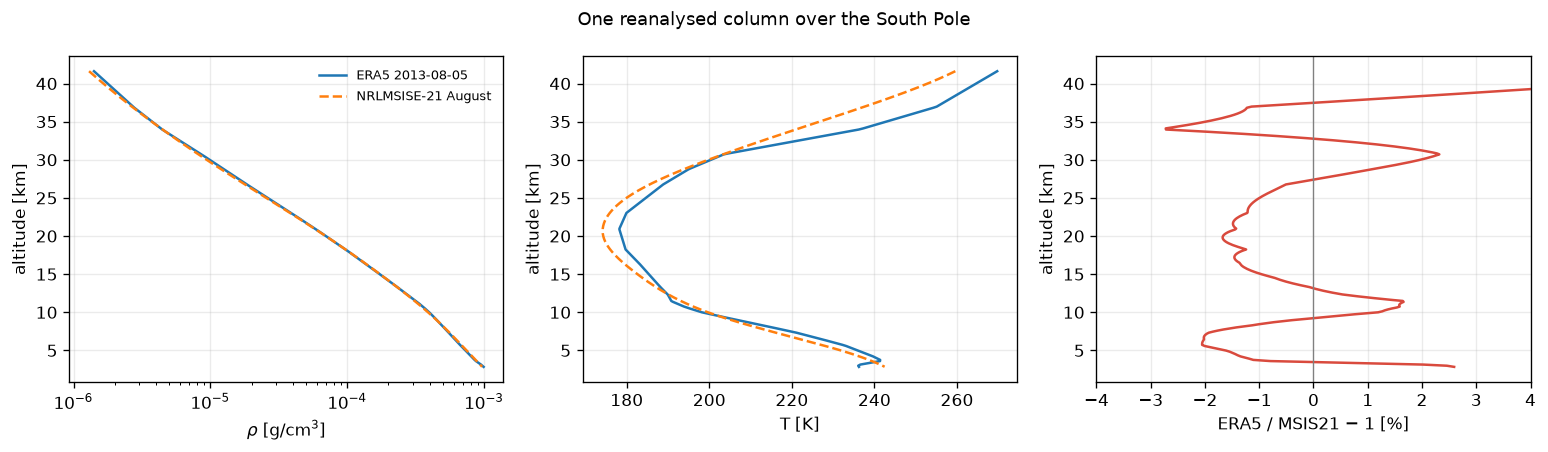

In [8]:
import MCEq.geometry.density_profiles as dp

table = dp.AtmosphereTable.load_from_csv(table_files[START_DATE])
print(table)

era5_atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),
                                  surface_elevation_m=SITE_ELEVATION_M, season=MONTH)
msis_atm = dp.MSIS21Atmosphere("SouthPole", MONTH)
for atm in (era5_atm, msis_atm):
    atm.set_theta(0.0)

# max_X is the grams of air in a 1 cm^2 tube from the top of the atmosphere down to
# the detector -- how much air a particle has to push through.
print(f"vertical column depth: ERA5 {era5_atm.max_X:.0f}, "
      f"NRLMSISE-21 {msis_atm.max_X:.0f} g/cm^2")

# Read the profiles back through the interface MCEq integrates, not from file.
X = np.geomspace(1.0, min(era5_atm.max_X, msis_atm.max_X) * 0.999, 300)


def profile(atm):
    """Density, temperature and height along a grid of slant depth."""
    h_cm = atm.X2h(X)
    T = np.array([float(atm.get_temperature(h)) for h in h_cm])
    return atm.X2rho(X), T, h_cm / 1e5


rho_e, T_e, h_e = profile(era5_atm)
rho_m, T_m, h_m = profile(msis_atm)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=120)
for values, T, label, style in ((rho_e, T_e, f"ERA5 {START_DATE}", "-"),
                                (rho_m, T_m, f"NRLMSISE-21 {MONTH}", "--")):
    axes[0].plot(values, h_e if label.startswith("ERA5") else h_m, style, label=label)
    axes[1].plot(T, h_e if label.startswith("ERA5") else h_m, style, label=label)
axes[2].plot(100 * (rho_e / rho_m - 1), h_e, color="#d94a3d")
axes[2].axvline(0, color="0.5", lw=0.8)
# The top of the column runs away to a much larger difference in very thin air and
# would squash everything below it, so the axis stops where the air still matters.
inner = h_e < 35.0
axes[2].set_xlim(np.floor(min(100 * (rho_e / rho_m - 1)[inner]) - 1),
                 np.ceil(max(100 * (rho_e / rho_m - 1)[inner]) + 1))

axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\rho$ [g/cm$^3$]")
axes[1].set_xlabel("T [K]")
axes[2].set_xlabel("ERA5 / MSIS21 $-$ 1 [%]")
for ax in axes:
    ax.set_ylabel("altitude [km]")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("One reanalysed column over the South Pole", fontsize=11)
fig.tight_layout()

## 7. From atmosphere to flux to rate

```python
mceq.solve()
mceq.get_solution("total_numu")                       # Flux per cm2 s sr GeV
mceq.n_particles("total_numu", min_energy_cutoff=100) # integrated, per cm2 s sr
```

* `get_solution` → a **differential flux**.
* `n_particles` → integrates it above a threshold. This notebook calls that the
  **rate** — but note it is still *per steradian*, and still not an event rate.
* `total_numu` is the neutrino only; `total_antinumu` is the antineutrino. A detector
  counts both, so everything below adds them.

**Many atmospheres at once.** Every scan below goes through
`mceq.solve_batch(conditions=[...])`, which solves one condition per entry of the list
and returns them together. `solution.K` is how many came back, and
`solution.get_solution(name, k=k)` reads out entry `k`, in the same order as the list
you passed.

In [9]:
import crflux.models as pm
from MCEq.core import MCEqRun

NU = ("total_numu", "total_antinumu")     # a detector counts both

mceq = MCEqRun(interaction_model="SIBYLL2.3E",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=era5_atm)
e_grid, e_widths = mceq.e_grid, mceq.e_widths
edge = float(mceq.e_bins[mceq.e_bins >= E_THRESHOLD][0])
first_bin = int(np.searchsorted(mceq.e_bins, E_THRESHOLD))


def rate(spectra):
    """Flux integrated above E_THRESHOLD, per cm^2 s sr. Works on arrays."""
    return np.sum((np.asarray(spectra) * e_widths)[..., first_bin:], axis=-1)


# Two atmospheres, one batched call: this is how every scan below is solved.
solved = mceq.solve_batch(conditions=[{"zenith_deg": 0.0, "density_model": a}
                                      for a in (era5_atm, msis_atm)])
era5_flux, msis_flux = (sum(solved.get_solution(n, k=k) for n in NU) for k in (0, 1))

print(f"\nrate above {edge:.0f} GeV: ERA5 {rate(era5_flux):.3e}, "
      f"MSIS21 {rate(msis_flux):.3e} /cm^2/s/sr "
      f"({100 * (rate(era5_flux) / rate(msis_flux) - 1):+.2f}%)")

MCEqRun::set_interaction_model(): SIBYLL23E
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, np.int64(0))).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, np.int64(0))).


MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)



rate above 100 GeV: ERA5 1.489e-06, MSIS21 1.500e-06 /cm^2/s/sr (-0.73%)


## 8. The rate across Antarctica

One atmosphere per grid node, one solve per node, **all in a single `solve_batch`
call**.

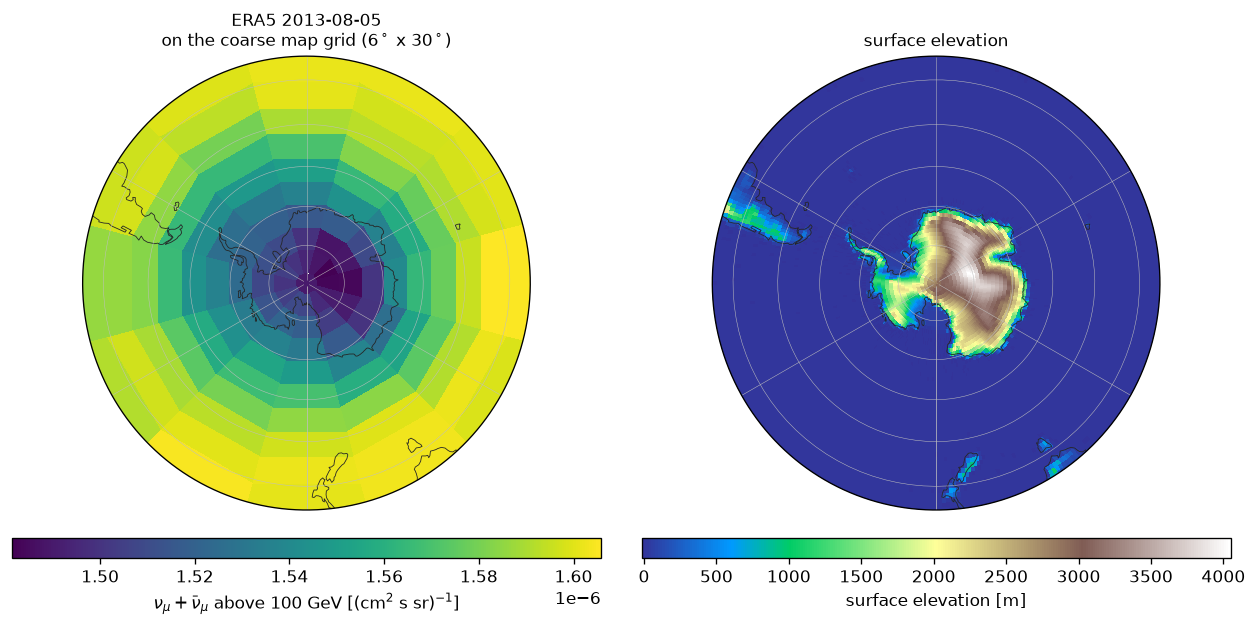

In [10]:
import cartopy.crs as ccrs
import matplotlib.path as mpath

polar = ccrs.SouthPolarStereo()
# The patch is a cap on the globe, so the map is drawn as a disc. Without this the
# axes are square and the corners outside the cap are filled with whatever the
# projection puts there.
DISC = mpath.Path(np.c_[0.5 + 0.5 * np.sin(np.linspace(0, 2 * np.pi, 200)),
                        0.5 + 0.5 * np.cos(np.linspace(0, 2 * np.pi, 200))])


def polar_map(ax, field, lat, lon, cmap, label, **kwargs):
    """A lon/lat field on a south polar map, limits taken from the field."""
    closed_lon = np.append(lon, lon[0] + 360.0)
    closed = np.concatenate([field, field[:, :1]], axis=1)
    mesh = ax.pcolormesh(closed_lon, lat, closed, transform=ccrs.PlateCarree(),
                         cmap=cmap, shading="auto", **kwargs)
    ax.coastlines(lw=0.5, color="0.15")
    ax.gridlines(lw=0.3, color="0.75")
    ax.set_extent([-180, 180, *LAT_RANGE], ccrs.PlateCarree())
    ax.set_boundary(DISC, transform=ax.transAxes)
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.9,
                 aspect=30, label=label)
    return mesh


map_j = np.arange(lat.size)[::LAT_STRIDE]
map_i = np.arange(lon.size)[::LON_STRIDE]
map_lat, map_lon = lat[map_j], lon[map_i]

# One atmosphere per node, each standing on its own cell's ground. MCEq measures
# height from sea level and will not take a negative ground, so the few points below
# it start at zero.
atmospheres = [
    dp.TabulatedAtmosphere(table, coord=(float(lon[i]), float(lat[j])),
                           surface_elevation_m=max(float(elevation_m[j, i]), 0.0))
    for j in map_j for i in map_i]
solution = mceq.solve_batch(
    conditions=[{"zenith_deg": 0.0, "density_model": a} for a in atmospheres])
spectra = np.array([sum(solution.get_solution(n, k=k) for n in NU)
                    for k in range(solution.K)])
today = rate(spectra).reshape(map_lat.size, map_lon.size)

fig = plt.figure(figsize=(11, 5.4), dpi=120)
ax = fig.add_subplot(1, 2, 1, projection=polar)
polar_map(ax, today, map_lat, map_lon, "viridis",
          rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV [(cm$^2$ s sr)$^{{-1}}$]")
ax.set_title(f"ERA5 {START_DATE}\non the coarse map grid "
             f"({LAT_STRIDE}$^\\circ$ x {LON_STRIDE}$^\\circ$)", fontsize=10)

ax = fig.add_subplot(1, 2, 2, projection=polar)
polar_map(ax, elevation_m, lat, lon, "terrain", "surface elevation [m]")
ax.set_title("surface elevation", fontsize=10)

for ax in fig.axes[::2]:
    ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
fig.tight_layout()

## 9. What IceCube actually sees

IceCube's clean muon-neutrino sample comes **from below**. An upward-going muon cannot
have been made in the sky overhead, because the Earth would have stopped it — so the
Earth itself is the veto.

**The catch is in the schematic below.** A neutrino arriving at 115° entered the
atmosphere about 50° of great circle away, over the Southern Ocean. That air is
nowhere near the detector. Tilting the pole's own column would simply be wrong.
`TabulatedLocationCentered` samples the table **where the shower actually is**,
averaging around the ring of impact points.

The schematic also explains something that otherwise looks backwards: the column depth
**falls** as the detector zenith grows. Further below the horizon means the shower
stands closer to *its own* vertical, so it crosses less air, not more.

(None,
 (np.float64(-1.63), np.float64(-0.3), np.float64(-0.3), np.float64(1.25)))

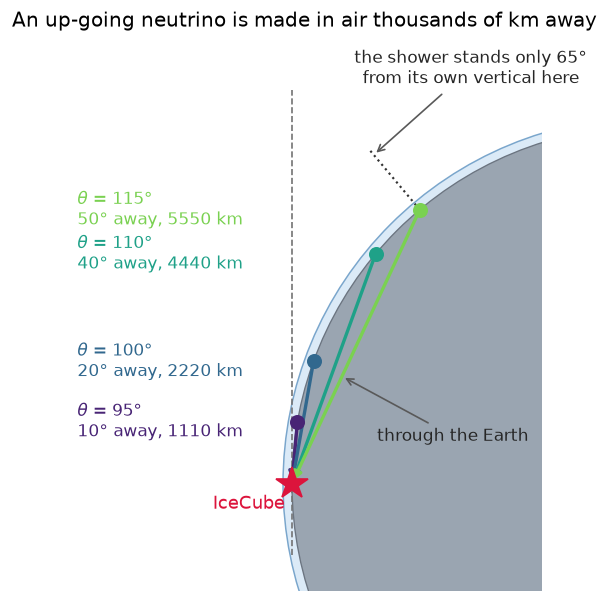

In [11]:
# Zoomed on the sector that matters.  The atmosphere shell is drawn thicker
# than it is; the entry points are placed on the surface, 2*theta - 180 degrees
# of great circle from the detector, which makes each drawn ray arrive at
# exactly its labelled zenith.
R, H = 1.0, 0.025
detector = np.array([-R, 0.0])

fig, ax = plt.subplots(figsize=(7.4, 6.0), dpi=120)
ax.add_patch(plt.Circle((0, 0), R + H, fc="#dbeaf7", ec="#7aa6cc", lw=0.9))
ax.add_patch(plt.Circle((0, 0), R, fc="#9aa5b1", ec="#6b7480", lw=0.8))
ax.plot([-R, -R], [-0.2, 1.1], "--", color="0.45", lw=1)

for theta, colour in zip([95, 100, 110, 115],
                         plt.cm.viridis(np.linspace(0.1, 0.8, 4))):
    away = 2 * theta - 180                      # degrees of great circle
    out = np.array([-np.cos(np.radians(away)), np.sin(np.radians(away))])
    ax.annotate("", xy=detector, xytext=R * out,
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=2.0))
    ax.plot(*(R * out), "o", color=colour, ms=8, zorder=4)
    ax.text(-1.60, R * out[1], f"$\\theta$ = {theta}°\n{away}° away, "
            f"{away * 111:.0f} km", color=colour, fontsize=10, va="center")

# At the far end the shower stands much closer to its own vertical.
far = R * np.array([-np.cos(np.radians(50)), np.sin(np.radians(50))])
ax.plot(*np.c_[far, 1.22 * far], ":", color="0.2", lw=1.3)
ax.annotate("the shower stands only 65°\nfrom its own vertical here",
            xy=1.20 * far, xytext=(-0.50, 1.12), fontsize=10, color="0.15",
            ha="center", arrowprops=dict(arrowstyle="->", color="0.35"))
ax.annotate("through the Earth", xy=(-0.86, 0.30), xytext=(-0.55, 0.12),
            fontsize=10, color="0.15", ha="center",
            arrowprops=dict(arrowstyle="->", color="0.35"))

ax.plot(*detector, "*", color="crimson", ms=20, zorder=5)
ax.text(-R - 0.02, -0.07, "IceCube", ha="right", fontsize=11, color="crimson")
ax.set_title("An up-going neutrino is made in air thousands of km away",
             fontsize=12)
ax.set_xlim(-1.63, -0.30), ax.set_ylim(-0.30, 1.25)
ax.set_aspect("equal"), ax.axis("off")

### Sampling the table where the shower is

`TabulatedLocationCentered` binds the table to a *detector* rather than to a grid
point. For each zenith angle it finds the impact ring and reads the table there. The
printout below asks the geometry where the shower is, instead of trusting a formula.

In [12]:
def detector_atmosphere(table):
    """The atmosphere IceCube sees, sampled where the shower actually is."""
    return dp.TabulatedLocationCentered(
        table,
        detector_coord=(SITE_LON, SITE_LAT),
        surface_elevation_m=SITE_ELEVATION_M,   # ice surface above sea level
        depth_m=SITE_DEPTH_M,                   # detector below that surface
        n_azimuth=N_AZIMUTH,                    # samples for the ring average
        max_theta=180.0,                        # needed to accept zenith > 90
        top_extension="msis21",                 # NRLMSIS 2.1 above the top level
        season=MONTH)


ic_atm = detector_atmosphere(table)

# Two calls per direction, on purpose. Naming one azimuth picks out a single impact
# point, which is what the table below can show; leaving azimuth out averages the air
# over the whole ring, which is what the rate is built on, because a detector sees
# every azimuth at once.
print(f"{'zenith':>7s}{'impact lat':>12s}{'distance':>10s}{'column depth':>14s}")
impact_lat, depth = [], []
for zenith in ZENITH_BAND:
    ic_atm.set_theta(float(zenith), azimuth_deg=0.0)   # one azimuth: a point
    impact_lat.append(ic_atm.current_impact_latitude)
    ic_atm.set_theta(float(zenith))                    # the averaged ring
    depth.append(ic_atm.max_X)
    if zenith in ZENITH_BAND[::2]:               # print every second one
        print(f"{zenith:7.0f}{impact_lat[-1]:+12.1f}"
              f"{abs(impact_lat[-1] - SITE_LAT) * 111:7.0f} km"
              f"{ic_atm.max_X:12.0f} g/cm^2")
impact_lat, depth = np.array(impact_lat), np.array(depth)

 zenith  impact lat  distance  column depth
     90       -88.6    157 km       15893 g/cm^2
     95       -80.1   1100 km       10633 g/cm^2
    100       -70.0   2215 km        5636 g/cm^2
    105       -60.0   3327 km        3868 g/cm^2
    110       -50.0   4438 km        2985 g/cm^2


    115       -40.0   5548 km        2433 g/cm^2


### The ring, drawn on the air it samples

Each coloured circle is one zenith angle's ring of impact points, on top of the ERA5
temperature near 20 km. The rings walk off the cold plateau and onto the **warm
Southern Ocean** — which is the whole reason a location-centred atmosphere is needed.

Text(0.5, 1.0, 'Where an up-going shower develops')

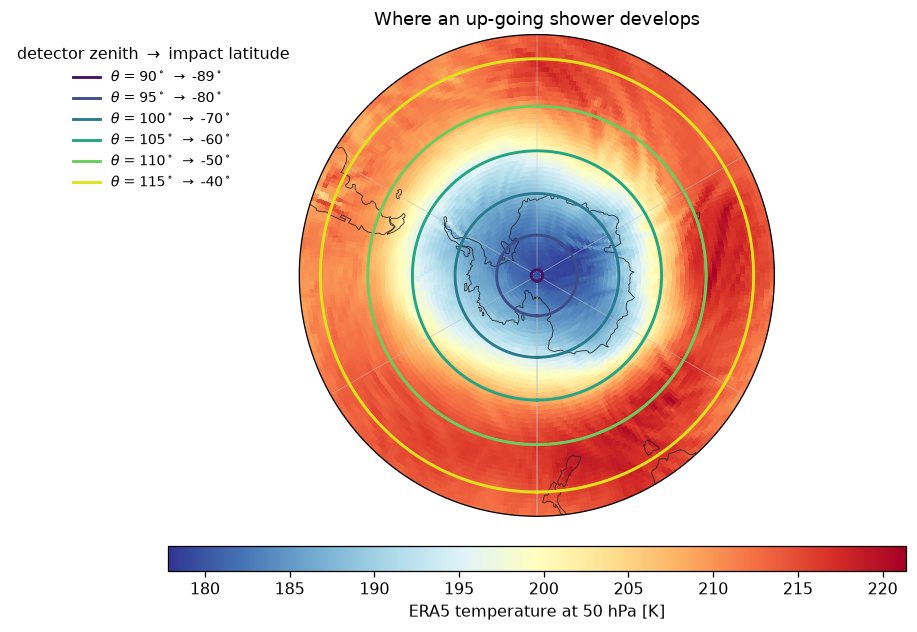

In [13]:
# The rings the azimuth average runs around, on the air they sample.
MAP_LEVEL = int(np.argmin(np.abs(p_hPa - 50.0)))
shown_T = day_temperature[START_DATE][..., MAP_LEVEL]

fig = plt.figure(figsize=(9.2, 6.8), dpi=115)
ax = fig.add_subplot(projection=polar)
mesh = polar_map(ax, shown_T, lat, lon, "RdYlBu_r",
                 f"ERA5 temperature at {p_hPa[MAP_LEVEL]:.0f} hPa [K]")

circle = np.linspace(-180, 180, 721)
shown = slice(None, None, 2)
for zenith, latitude, colour in zip(ZENITH_BAND[shown], impact_lat[shown],
                                    plt.cm.viridis(np.linspace(0.05, 0.95, 6))):
    ax.plot(circle, np.full_like(circle, latitude), color=colour, lw=1.8,
            transform=ccrs.Geodetic(),
            label=rf"$\theta$ = {zenith:.0f}$^\circ$ $\to$ {latitude:.0f}$^\circ$")
ax.plot(SITE_LON, SITE_LAT, "k*", ms=16, transform=ccrs.PlateCarree(), zorder=5)
ax.legend(loc="upper left", bbox_to_anchor=(-0.62, 1.0), fontsize=8.5,
          frameon=False, title="detector zenith $\\to$ impact latitude")
ax.set_title("Where an up-going shower develops", fontsize=11)

### The zenith scan

Three panels: the rate, how much air the path actually crosses, and what the
reanalysis is worth against climatology.

ERA5         band-integrated 8.028e-06 /cm^2/s
MSIS21       band-integrated 8.068e-06 /cm^2/s


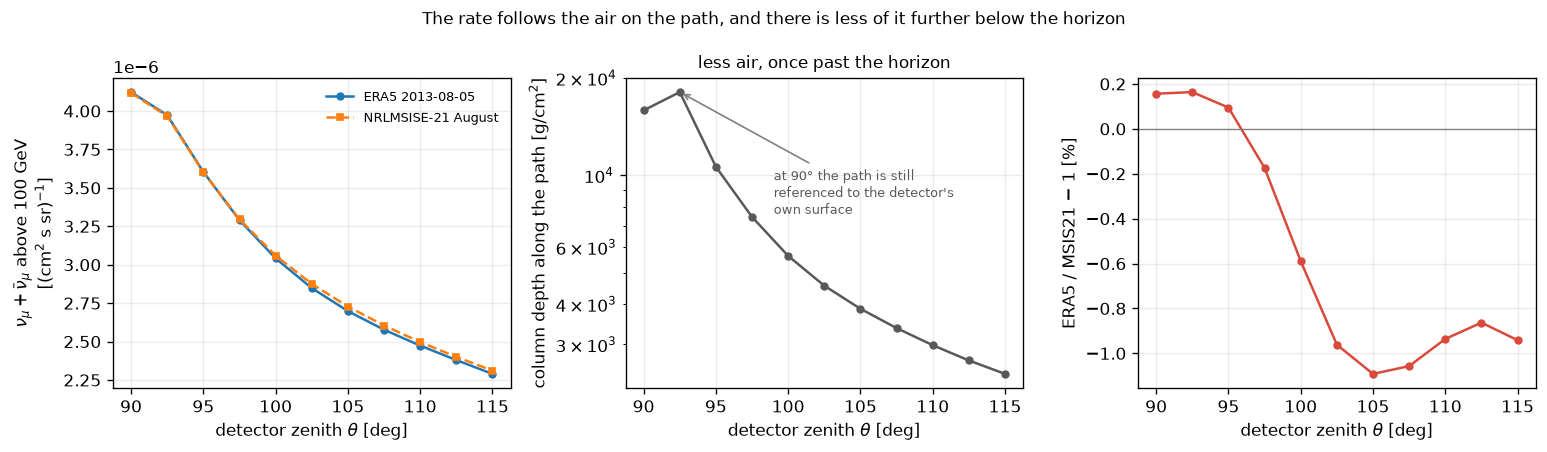

In [14]:
def integrate_band(theta_deg, flux_per_sr):
    """2*pi * int flux dcos(theta): per cm^2 s, over the band and all azimuths."""
    mu = np.cos(np.radians(theta_deg))
    order = np.argsort(mu)
    return 2 * np.pi * np.trapezoid(flux_per_sr[order], mu[order])


msis_ic = dp.MSIS21IceCubeCentered("SouthPole", MONTH)
solved = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": model}
    for model in (ic_atm, msis_ic) for z in ZENITH_BAND])
zenith_rate = rate(np.array([sum(solved.get_solution(n, k=k) for n in NU)
                             for k in range(solved.K)])).reshape(2, -1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=120)
for row, label, style in ((0, f"ERA5 {START_DATE}", "-o"),
                          (1, f"NRLMSISE-21 {MONTH}", "--s")):
    axes[0].plot(ZENITH_BAND, zenith_rate[row], style, ms=4, label=label)
axes[0].set_ylabel(rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV"
                   "\n" r"[(cm$^2$ s sr)$^{-1}$]")
axes[0].legend(fontsize=8, frameon=False)

axes[1].semilogy(ZENITH_BAND, depth, "-o", ms=4, color="0.35")
axes[1].set_ylabel(r"column depth along the path [g/cm$^2$]")
axes[1].set_title("less air, once past the horizon", fontsize=10)
# Below the peak, not above it: at depth[1] * 1.1 the label lands on the title.
axes[1].annotate("at 90° the path is still\nreferenced to the detector's\nown surface",
                 xy=(92.5, depth[1]), xytext=(99, depth[1] * 0.42), fontsize=8,
                 color="0.35", arrowprops=dict(arrowstyle="->", color="0.5"))

axes[2].plot(ZENITH_BAND, 100 * (zenith_rate[0] / zenith_rate[1] - 1), "-o",
             ms=4, color="#d94a3d")
axes[2].axhline(0, color="0.5", lw=0.8)
axes[2].set_ylabel("ERA5 / MSIS21 $-$ 1 [%]")
for ax in axes:
    ax.set_xlabel(r"detector zenith $\theta$ [deg]")
    ax.grid(alpha=0.25)
fig.suptitle("The rate follows the air on the path, and there is less of it "
             "further below the horizon", fontsize=10)
fig.tight_layout()

for row, label in ((0, "ERA5"), (1, "MSIS21")):
    print(f"{label:12s} band-integrated "
          f"{integrate_band(ZENITH_BAND, zenith_rate[row]):.3e} /cm^2/s")

### Seven days, as IceCube would see them

The up-going band on the same seven days.

  2013-08-05  done


  2013-08-06  done


  2013-08-07  done


  2013-08-08  done


  2013-08-09  done


  2013-08-10  done


  2013-08-11  done


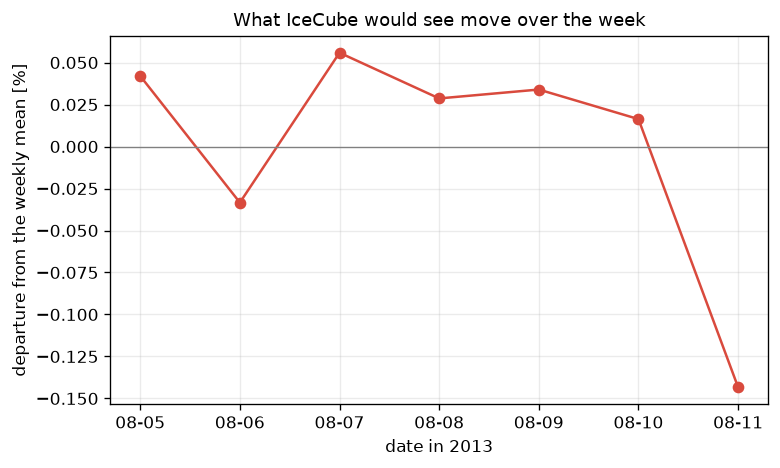

In [15]:
band_rate = []
for date in dates:
    day_atm = detector_atmosphere(dp.AtmosphereTable.load_from_csv(table_files[date]))
    day = mceq.solve_batch(conditions=[
        {"zenith_deg": float(z), "density_model": day_atm} for z in ZENITH_BAND])
    per_sr = rate(np.array([sum(day.get_solution(n, k=k) for n in NU)
                            for k in range(day.K)]))
    band_rate.append(integrate_band(ZENITH_BAND, per_sr))
    print(f"  {date}  done")
band_rate = np.array(band_rate)

fig, ax = plt.subplots(figsize=(6.6, 4), dpi=120)
ax.plot(range(len(dates)), 100 * (band_rate / band_rate.mean() - 1), "-o",
        color="#d94a3d")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_xticks(range(len(dates)), [d[5:] for d in dates])
ax.set_ylabel("departure from the weekly mean [%]")
ax.set_xlabel(f"date in {START_DATE[:4]}")
ax.grid(alpha=0.25)
ax.set_title("What IceCube would see move over the week", fontsize=11)
fig.tight_layout()